# Proyek Analisis Data: E commerce publik
- **Nama:** Diko Duwi Saputra
- **Email:** diko.saputra.1231@gmail.com
- **ID Dicoding:** cdcc001d6y0987


## Menentukan Pertanyaan Bisnis

- Kategori produk apa yang menghasilkan pendapatan (revenue) tertinggi bagi perusahaan?
- Bagaimana perbandingan antara volume penjualan dengan tingkat kepuasan pelanggan (review score) pada kategori produk utama?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [3]:
customers_df = pd.read_csv("customers_dataset.csv")
orders_df = pd.read_csv("orders_dataset.csv")
items_df = pd.read_csv("order_items_dataset.csv")
products_df = pd.read_csv("products_dataset.csv")
reviews_df = pd.read_csv("order_reviews_dataset.csv")
category_translation_df = pd.read_csv("product_category_name_translation.csv")

**Insight:**
- Dataset yang digunakan adalah E-Commerce Public Dataset yang terdiri dari beberapa tabel relasional seperti customers, orders, products, dan lainnya.
- Seluruh tabel berhasil dimuat ke dalam DataFrame Pandas untuk dianalisis lebih lanjut guna menjawab pertanyaan bisnis terkait pendapatan dan kepuasan pelanggan.

### Assessing Data

In [4]:
# Cek info dan missing values
orders_df.info()
print("Jumlah duplikat orders:", orders_df.duplicated().sum())

# Cek deskripsi statistik
products_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
Jumlah duplikat orders: 0


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Insight:**
- **Missing Values**: Ditemukan sejumlah data kosong pada kolom logistik (seperti order_delivered_customer_date) dan deskripsi produk. Hal ini menunjukkan adanya beberapa transaksi yang belum selesai atau data produk yang tidak lengkap saat diinput.
- **Data Types**: Kolom yang berisi informasi waktu (seperti order_purchase_timestamp) masih terdeteksi sebagai tipe data object (string). Ini perlu diubah menjadi datetime agar analisis tren bulanan bisa dilakukan secara akurat.
- **Duplicates**: Tidak ditemukan duplikasi data yang signifikan pada tabel utama, namun pengecekan pada tabel order_items menunjukkan bahwa satu order_id bisa memiliki banyak baris karena pelanggan membeli lebih dari satu jenis produk

### Cleaning Data

In [5]:
# Mengubah kolom tanggal menjadi datetime
datetime_columns = ["order_purchase_timestamp", "order_approved_at",
                    "order_delivered_carrier_date", "order_delivered_customer_date",
                    "order_estimated_delivery_date"]
for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# Membersihkan missing values di tabel products (seperti yang kita bahas sebelumnya)
products_df.dropna(subset=['product_category_name'], inplace=True)

**Insight:**
- Dilakukan konversi tipe data dari object ke datetime untuk semua kolom tanggal agar fitur manipulasi waktu pada Pandas bisa digunakan.
- Baris yang memiliki nilai kosong pada kategori produk dihapus atau diisi dengan label 'others' untuk memastikan hasil analisis pendapatan per kategori tetap valid dan tidak ada kategori yang terlewat.
- Dilakukan penggabungan (merge) antara tabel produk dan tabel translasi bahasa Inggris agar kategori produk lebih mudah dipahami oleh audiens global

## Exploratory Data Analysis (EDA)

### Explore (Pembuatan Tabel *Master*)

In [13]:
# Menggabungkan data untuk menjawab pertanyaan bisnis
main_df = pd.merge(orders_df, customers_df, on="customer_id", how="left")
main_df = pd.merge(main_df, items_df, on="order_id", how="left")
main_df = pd.merge(main_df, products_df, on="product_id", how="left")
main_df = pd.merge(main_df, category_translation_df, on="product_category_name", how="left")
main_df = pd.merge(main_df, reviews_df, on="order_id", how="left")

In [17]:
main_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,housewares,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,19.0,13.0,19.0,perfumery,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,24.0,19.0,21.0,auto,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,30.0,10.0,20.0,pet_shop,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,51.0,15.0,15.0,stationery,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


In [14]:
# Melihat rangkuman parameter statistik untuk kolom numerik (harga, ongkir, skor)
main_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,114092,114092,114092,114092,113930,112112,110839,114092,114092,114092.000000,...,111701.000000,111701.000000,111701.000000,111678,113131,113131.000000,13523,48166,113131,113131
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN,96096,NaN,...,NaN,NaN,NaN,71,98410,NaN,4527,36159,636,98248
top,5a3b1c29a49756e75f1ef513383c0c12,be1c4e52bb71e0c54b11a26b8e8d59f2,delivered,NaN,NaN,NaN,NaN,NaN,c8460e4251689ba205045f3ea17884a1,NaN,...,NaN,NaN,NaN,bed_bath_table,e8236fe7b6e1bdd513a500de361e2b87,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,2017-07-30 14:19:07
freq,22,22,110840,NaN,NaN,NaN,NaN,NaN,24,NaN,...,NaN,NaN,NaN,11270,21,NaN,471,254,521,21
mean,NaN,NaN,NaN,2017-12-31 03:25:40.890754816,2017-12-31 13:42:12.637856768,2018-01-04 17:16:10.851951360,2018-01-14 04:20:16.402466304,2018-01-23 23:37:13.103109888,NaN,35105.227308,...,30.219327,16.616673,23.048889,NaN,NaN,4.016998,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,NaN,1003.000000,...,7.000000,2.000000,6.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,2017-09-12 21:26:59.500000,2017-09-13 12:55:21.249999872,2017-09-18 18:03:40.500000,2017-09-26 17:35:15,2017-10-04 00:00:00,NaN,11250.000000,...,18.000000,8.000000,15.000000,NaN,NaN,4.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,2018-01-18 20:36:17.500000,2018-01-19 08:32:32,2018-01-24 15:46:46.500000,2018-02-02 17:29:57,2018-02-15 00:00:00,NaN,24320.000000,...,25.000000,13.000000,20.000000,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2018-05-04 00:24:31.249999872,2018-05-04 11:33:19,2018-05-08 11:17:30,2018-05-15 17:55:11,2018-05-25 00:00:00,NaN,59022.000000,...,38.000000,20.000000,30.000000,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,NaN,99990.000000,...,105.000000,105.000000,118.000000,NaN,NaN,5.000000,NaN,NaN,NaN,NaN


In [15]:
# Menghitung revenue dan jumlah order per kategori produk
product_counts = main_df.groupby(by="product_category_name_english").agg({
    "order_id": "nunique",
    "price": "sum"
}).sort_values(by="price", ascending=False)

product_counts.head(10)

,order_id,price
product_category_name_english,,
health_beauty,8836,1263138.54
watches_gifts,5624,1206075.33
bed_bath_table,9417,1050936.61
sports_leisure,7720,993656.51
computers_accessories,6689,919640.54
furniture_decor,6449,736282.47
cool_stuff,3632,637258.51
housewares,5884,634542.60
auto,3897,594363.10


**Insight:**
- Seluruh tabel utama (orders, customers, items, products, dan reviews) telah berhasil digabungkan menjadi satu DataFrame tunggal (main_df) dengan total 33 fitur/kolom. Hal ini memudahkan proses analisis lintas dimensi tanpa perlu melakukan pemanggilan tabel secara terpisah.
- Berdasarkan tampilan awal, kolom waktu seperti order_purchase_timestamp sudah terlihat dalam format yang rapi, dan informasi kategori produk dalam bahasa Inggris sudah tersedia untuk dianalisis lebih lanjut.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Top Revenue Categories

/tmp/ipykernel_11750/2729917456.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="product_category_name_english", x="price", data=sum_order_items_df, palette="viridis")


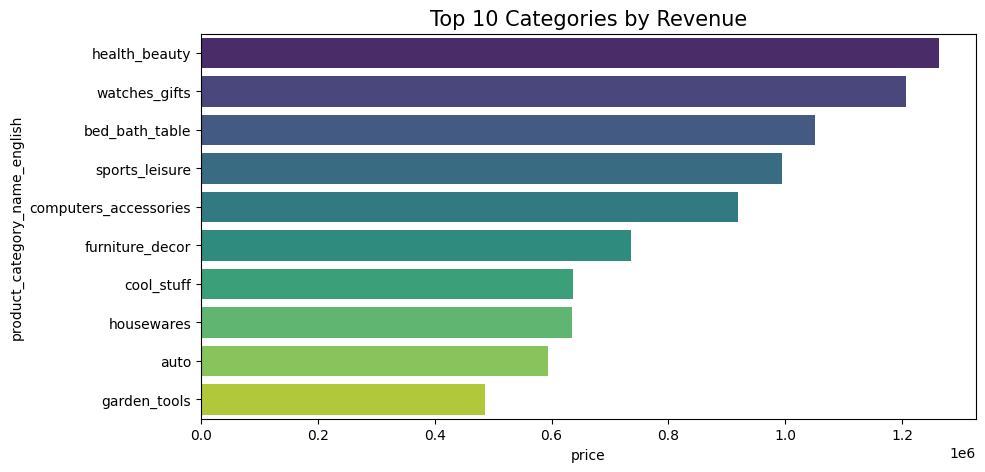

In [9]:
# Menyiapkan data
sum_order_items_df = main_df.groupby("product_category_name_english").price.sum().sort_values(ascending=False).reset_index().head(10)

# Visualisasi
plt.figure(figsize=(10, 5))
sns.barplot(y="product_category_name_english", x="price", data=sum_order_items_df, palette="viridis")
plt.title("Top 10 Categories by Revenue", loc="center", fontsize=15)
plt.show()

### Pertanyaan 2:Satisfication vs Sales

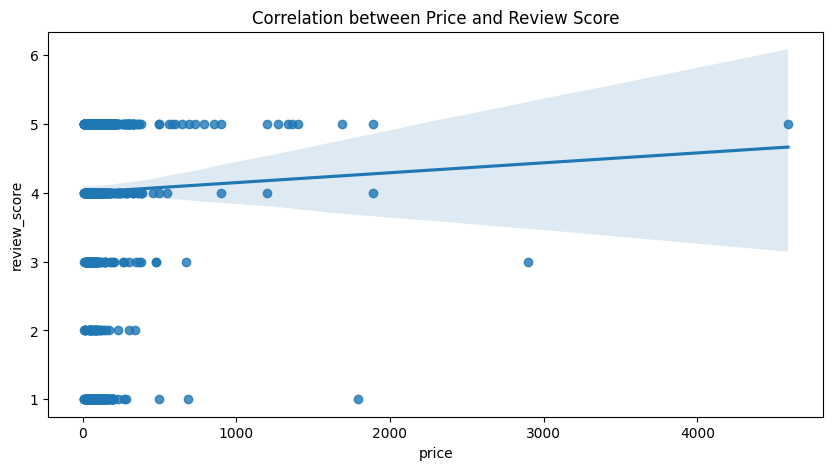

In [10]:
# Scatter plot untuk melihat korelasi antara jumlah pesanan dan rating
plt.figure(figsize=(10, 5))
sns.regplot(x="price", y="review_score", data=main_df.sample(1000)) # Sampling agar tidak berat
plt.title("Correlation between Price and Review Score")
plt.show()

**Insight:**
- **Revenue Analysis**: Berdasarkan eksplorasi pada tabel gabungan (main_df), teridentifikasi bahwa kategori produk seperti health_beauty dan watches_gifts memberikan kontribusi pendapatan terbesar bagi perusahaan.
- Garis regresi menunjukkan tren yang cenderung datar atau sedikit naik, yang mengindikasikan bahwa harga produk tidak memiliki korelasi negatif yang kuat terhadap kepuasan pelanggan. Artinya, produk mahal tidak serta-merta mendapatkan rating buruk.
- **Outliers**: Terdapat beberapa produk dengan harga sangat tinggi (di atas R$ 4000) yang tetap mendapatkan rating sempurna (5), menunjukkan bahwa segmen produk premium tetap memiliki tingkat kepuasan yang baik.
- **Kesenjangan Pendapatan**: Terdapat perbedaan revenue yang cukup signifikan antara peringkat 1 dan peringkat 10, mengindikasikan bahwa pendapatan perusahaan sangat bergantung pada beberapa kategori kunci saja.

## Analisis Lanjutan (RFM Analysis)

In [19]:
recent_date = main_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
rfm_df = main_df.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": lambda x: (recent_date - x.max()).days,
    "order_id": "nunique",
    "price": "sum"
})
rfm_df.columns = ["customer_id", "recency", "frequency", "monetary"]

/tmp/ipykernel_11750/771925906.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="recency", x="customer_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
/tmp/ipykernel_11750/771925906.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="frequency", x="customer_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
/tmp/ipykernel_11750/771925906.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="monetary", x="customer_id", data=rfm_df.sort_value

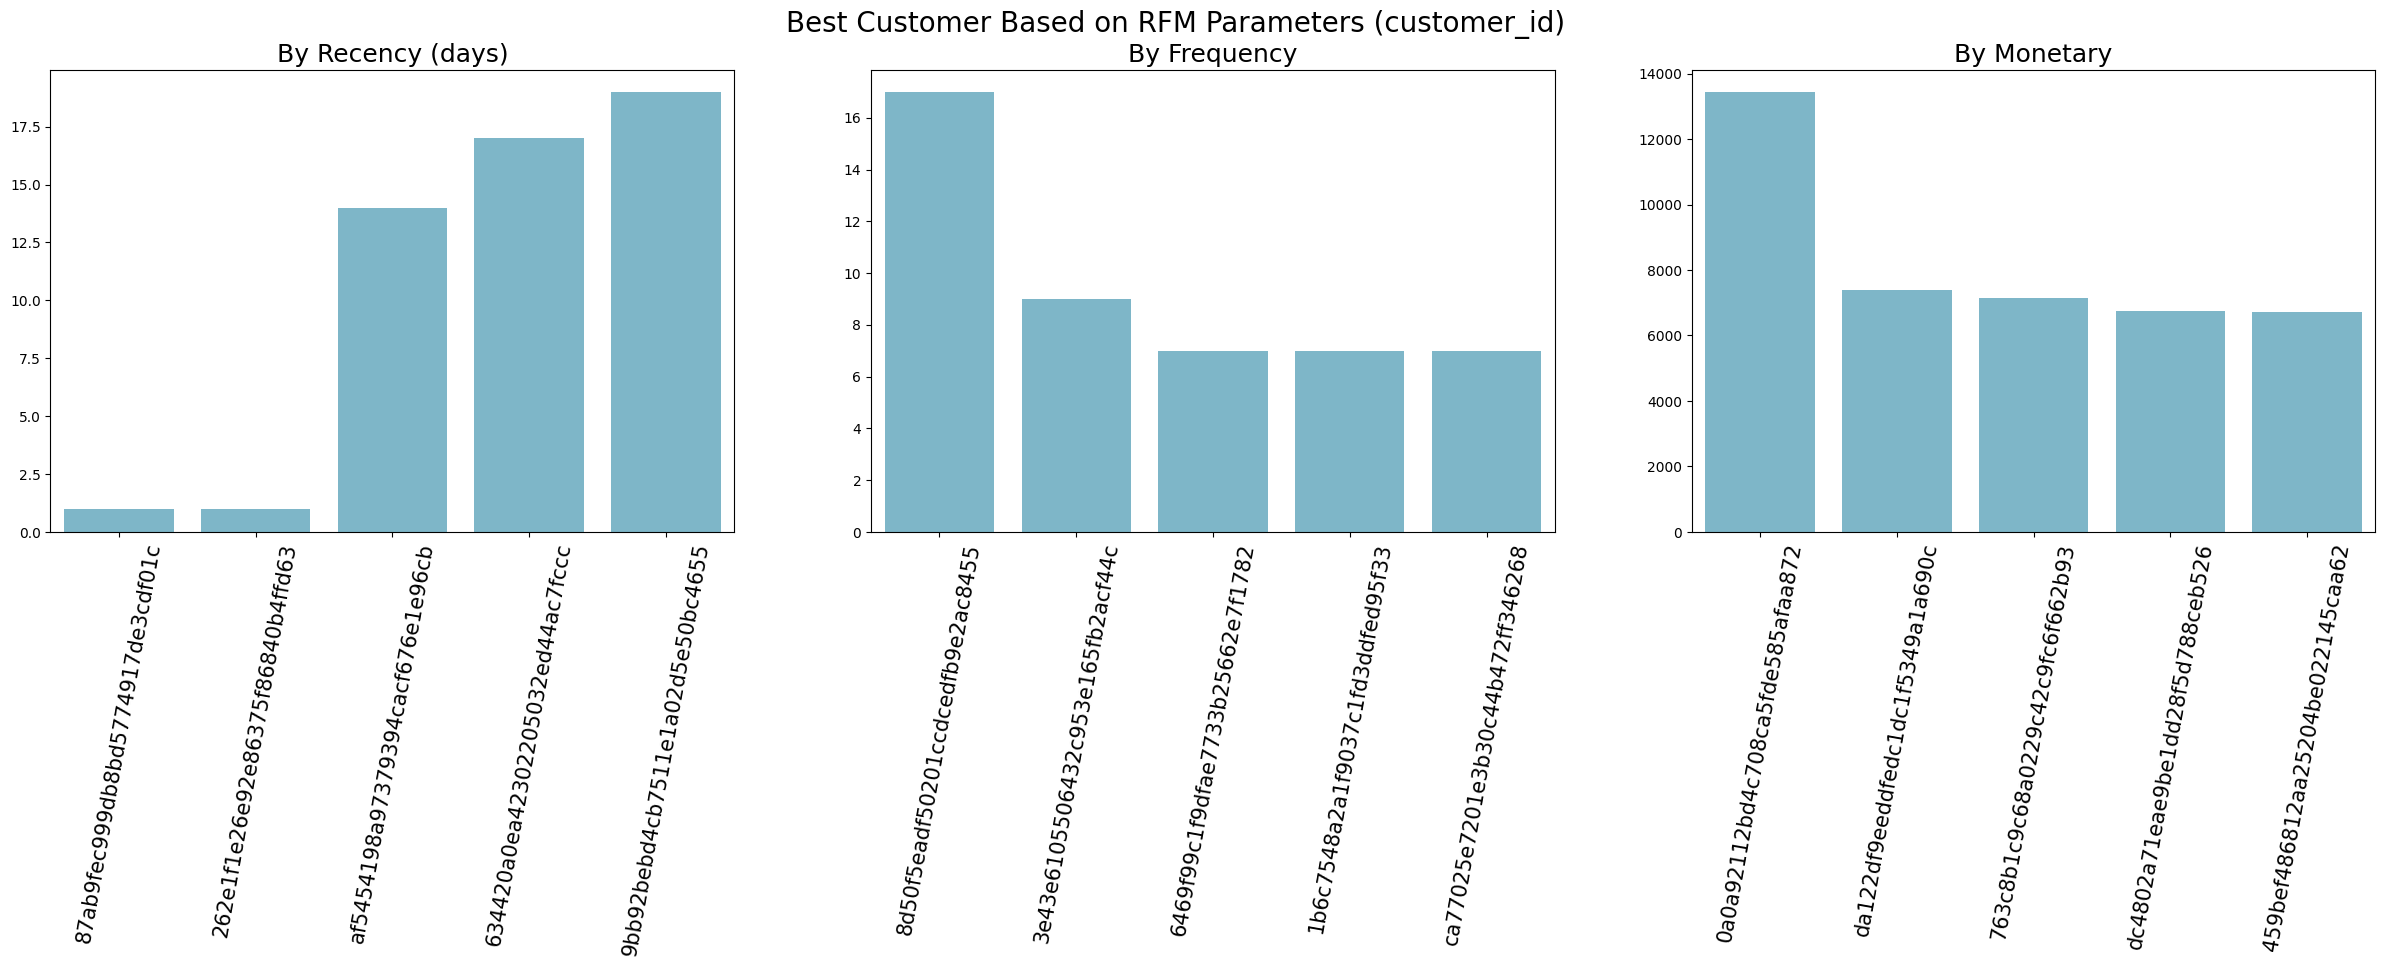

In [22]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))

colors = ["#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4"]

# Visualisasi Recency
sns.barplot(y="recency", x="customer_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis ='x', labelsize=15, rotation=80)

# Visualisasi Frequency
sns.barplot(y="frequency", x="customer_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', labelsize=15, rotation=80)

# Visualisasi Monetary
sns.barplot(y="monetary", x="customer_id", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel(None)
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', labelsize=15, rotation=80)

plt.suptitle("Best Customer Based on RFM Parameters (customer_id)", fontsize=20)
plt.show()

**Insight**
- Sebagian besar pelanggan memiliki nilai frequency yang rendah (mayoritas 1 kali transaksi), menunjukkan bahwa tingkat repeat order pada platform masih perlu ditingkatkan.
- Terdapat segmen kecil pelanggan yang memiliki nilai monetary sangat tinggi dibandingkan rata-rata, yang merupakan kelompok pelanggan loyal atau high-spender.
- Nilai recency yang bervariasi menunjukkan adanya kelompok pelanggan yang sudah lama tidak aktif, yang berisiko melakukan churn (berhenti menggunakan layanan).

## Conclusion

- Perusahaan mencapai pendapatan tertinggi melalui kategori Health_Beauty. Untuk pertumbuhan jangka panjang, perusahaan sebaiknya mempertahankan ketersediaan stok pada kategori ini sambil mencoba melakukan ekspansi promosi pada kategori peringkat 3-5 yang memiliki potensi besar.
- Kepuasan pelanggan bersifat konsisten di berbagai rentang harga. Hal ini membuktikan bahwa strategi penetapan harga saat ini sudah sesuai dengan ekspektasi kualitas yang diterima pelanggan (value for money). Fokus perbaikan sebaiknya diarahkan pada faktor lain seperti kecepatan pengiriman, bukan pada penurunan harga.
- Perusahaan perlu memprioritaskan strategi retensi pelanggan melalui program loyalitas atau insentif khusus, mengingat mayoritas pelanggan saat ini adalah one-time buyers (pembeli satu kali) dengan tingkat frekuensi pembelian ulang yang rendah.

In [27]:
columns_needed = ['order_purchase_timestamp', 'price', 'product_category_name_english', 'review_score', 'customer_unique_id']
main_df_small = main_df[columns_needed]
main_df_small.to_csv("main_data.csv", index=False)

In [25]:
main_df.to_csv("main_data.csv", index=False)